```text
Capital analysis
├── Import & Setup
├── PD and LGD estimation
└── Capital estimation (Monte-Carlo)
    ├── Capital concentration - on PD x LGD
    ├── Capital concentration - on PD 
    └── Capital reduction    
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import aggregate_el_on_pd, estimate_capital_reduction, show_approval_vs_reduction
from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe, apply_pipe_LGD, estimate_capital
from src.plots import my_heatmap
from src.preprocessing import my_input_load, ReplaceMinusOne
from src.validation import validate_predictions

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = my_input_load(2019, 2020)
portfolio, dr_summary = create_target_def12(portfolio)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


## PD and LGD estimation

In [4]:
# import pipelines

import joblib
pipeline_pd  = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_lgd = joblib.load("../models/PIPELINE_LGD_Amount.pkl")

In [5]:
# apply pipelines

portfolio = apply_pipe(portfolio, pipeline_pd)
portfolio = apply_pipe_LGD(portfolio, pipeline_lgd)

In [6]:
# validate model output

validate_predictions(portfolio)

----------------------------------------
MODEL OUTPUT VALIDATION
----------------------------------------


,PD,LGD
Min,0.000,0.000
Mean,0.150,0.132
Max,0.595,0.224
NaNs,0.000,0.000


## Capital estimation (Monte-Carlo)

#### Capital concentration - on PD x LGD

Portfolio EAD :  116382285.0
Portfolio EL  :  3008986.5963403024
selected variable:  EL
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.029282  0.043009  0.058625  0.085654  0.145875
50–70%   0.035146  0.072426  0.105585  0.144007  0.259950
70–100%  0.000582  0.001784  0.004046  0.006260  0.007769


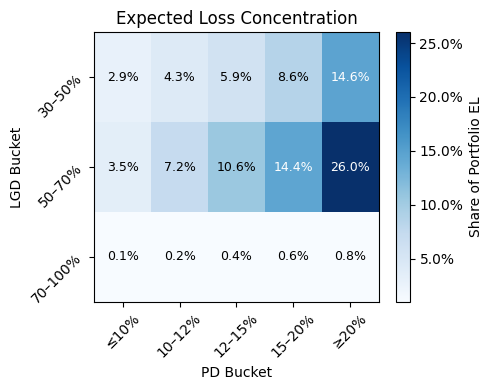

selected variable:  CAP
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.028848  0.042679  0.056345  0.084343  0.143020
50–70%   0.035381  0.069449  0.107718  0.146491  0.262292
70–100%  0.001052  0.002166  0.004326  0.007598  0.008290


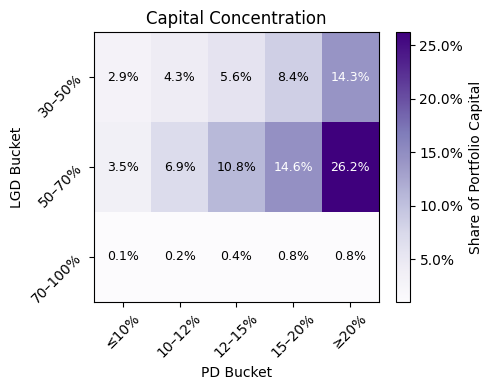

In [7]:
# capital estimation 'monte-carlo' with observed LGDs

capital_montecarlo, _, _= estimate_capital(portfolio, method="monte-carlo", column_lgd="LossGivenDefault", allocate=True, verbose=False)
my_heatmap(capital_montecarlo, variable="EL" , column_lgd="LossGivenDefault")
my_heatmap(capital_montecarlo, variable="CAP", column_lgd="LossGivenDefault")

#### Capital concentration - on PD

In [8]:
bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

table_EL   = aggregate_el_on_pd(capital_montecarlo, "EL"   , bins)
table_CAP  = aggregate_el_on_pd(capital_montecarlo, "CAP"  , bins)

--------------------------------------------------
OVERALL STATS: 
EL sum = 3,008,987
--------------------------------------------------
--------------------------------------------------


prob_bin,"(0.0, 0.05]","(0.05, 0.1]","(0.1, 0.15]","(0.15, 0.2]","(0.2, 0.25]","(0.25, 0.3]","(0.3, 0.35]","(0.35, 0.4]","(0.4, 0.5]","(0.5, 0.6]","(0.6, 0.7]","(0.7, 0.8]","(0.8, 0.9]","(0.9, 1.0]"
Count,738,"10,459","16,896","11,279","5,127","2,185","1,066",483,193,20,0,0,0,0
Avg_PD,4.25%,8.04%,12.46%,17.21%,22.14%,27.18%,32.24%,37.06%,43.18%,53.21%,nan%,nan%,nan%,nan%
Sum_EL,"6,725","239,400","749,712","829,972","541,623","301,618","195,317","103,793","37,036","3,791",0,0,0,0
Share_EL,0.22%,7.96%,24.92%,27.58%,18.00%,10.02%,6.49%,3.45%,1.23%,0.13%,0.00%,0.00%,0.00%,0.00%


--------------------------------------------------
--------------------------------------------------
OVERALL STATS: 
EL sum = 243,609
--------------------------------------------------
--------------------------------------------------


prob_bin,"(0.0, 0.05]","(0.05, 0.1]","(0.1, 0.15]","(0.15, 0.2]","(0.2, 0.25]","(0.25, 0.3]","(0.3, 0.35]","(0.35, 0.4]","(0.4, 0.5]","(0.5, 0.6]","(0.6, 0.7]","(0.7, 0.8]","(0.8, 0.9]","(0.9, 1.0]"
Count,738,"10,459","16,896","11,279","5,127","2,185","1,066",483,193,20,0,0,0,0
Avg_PD,4.25%,8.04%,12.46%,17.21%,22.14%,27.18%,32.24%,37.06%,43.18%,53.21%,nan%,nan%,nan%,nan%
Sum_EL,509,"19,282","59,897","67,964","44,063","24,122","16,656","7,906","2,855",355,0,0,0,0
Share_EL,0.21%,7.92%,24.59%,27.90%,18.09%,9.90%,6.84%,3.25%,1.17%,0.15%,0.00%,0.00%,0.00%,0.00%


--------------------------------------------------


#### Capital reduction

running Monte-Carlo...
Portfolio EAD :  116382285.0
Portfolio EL  :  3008986.5963403024
running Monte-Carlo...
Portfolio EAD :  101875452.0
Portfolio EL  :  2367430.7098771743
running Monte-Carlo...
Portfolio EAD :  85711784.0
Portfolio EL  :  1825808.171902294
running Monte-Carlo...
Portfolio EAD :  56308310.0
Portfolio EL  :  995836.2577520816
running Monte-Carlo...
Portfolio EAD :  19689686.0
Portfolio EL  :  246124.58596077425
running Monte-Carlo...
Portfolio EAD :  9080046.0
Portfolio EL  :  90412.10530614704
running Monte-Carlo...
Portfolio EAD :  1071900.0
Portfolio EL  :  6724.536957504115


PD Threshold,Approval Rate,Portfolio EAD,Expected Loss,Expected Loss (MC),Economic Capital,EL Reduction,EC Reduction
1.00,100.0%,116.4 M€,3.01 M€,3.01 M€,244 k€,0 %,0 %
0.25,91.9%,101.9 M€,2.37 M€,2.37 M€,219 k€,21 %,10 %
0.20,81.3%,85.7 M€,1.83 M€,1.83 M€,176 k€,39 %,28 %
0.15,58.0%,56.3 M€,1.00 M€,1.00 M€,137 k€,67 %,44 %
0.10,23.1%,19.7 M€,0.25 M€,0.25 M€,67 k€,92 %,72 %
0.08,11.1%,9.1 M€,0.09 M€,0.09 M€,37 k€,97 %,85 %
0.05,1.5%,1.1 M€,0.01 M€,0.01 M€,12 k€,100 %,95 %


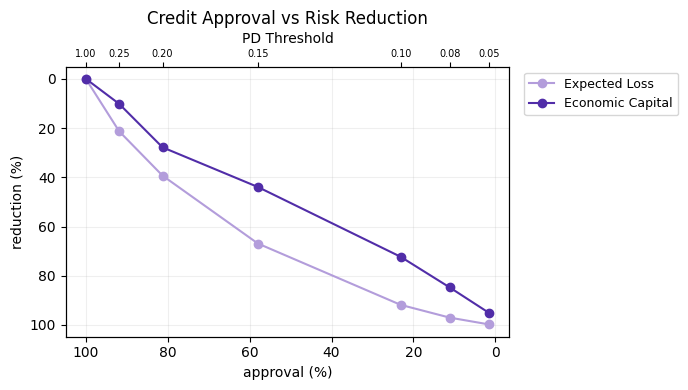

In [9]:
# how do expected loss and economic capital respond 
# to a decreasing PD acceptance threshold

pd_thresholds = [1.00, 0.25, 0.20, 0.15, 0.10, 0.08, 0.05]
reduction = estimate_capital_reduction(portfolio, pd_thresholds)
show_approval_vs_reduction(reduction)